# Two Fundamental Experiments → The Qubit
### A hands-on to the double-slit and Stern–Gerlach experiments

Quantum Computing Education Series by Trinexis 2026

This notebook *simulates*, from scratch, the two experiments (double-slit and Stern–Gerlach experiments) and
shows, in a step by step manner, how they assemble into the building blocks of quantum computing:

> **An important idea:** *when alternatives are indistinguishable, complex
> amplitudes add; the probability of an outcome is the squared magnitude of its amplitude.*
> The **double slit** discovers this law, and **quantum algorithms** would eventually exploit it.


**Learning objectives.** By the end of this notebook, one should be able to understand, with a working simulation in hand:

1. Probability amplitudes and the Born rule
2. Why *which-path* information destroys interference
3. How a single quantum measurement yields one of two outcomes (the qubit)
4. Superposition and measurement bases
5. The Bloch sphere
6. Single-qubit gates
7. How quantum algorithms harness *interference*.

In [2]:
# === Setup (run this first) ===========================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection
%matplotlib inline

np.random.seed(42)                      # reproducible randomness
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("Setup complete, numpy", np.__version__, "| matplotlib ready.")

Setup complete, numpy 2.0.2 | matplotlib ready.


---
# Part I, The Double-Slit Experiment
*Following Feynman, Lectures on Physics Vol. III, Ch. 1 ("Quantum Behavior").*

Feynman compares three experiments with the same two-slit geometry.

## 1.1 Bullets, classical particles, *probabilities add*

Indestructible bullets arrive in lumps. Each bullet goes through **either** hole 1 **or** hole 2,
scatters, and lands somewhere on the screen. We record where many bullets land with only hole 1
open (`P1`), only hole 2 open (`P2`), and both open (`P12`).

**Claim to verify:** $P_{12} = P_1 + P_2$, *no interference.*

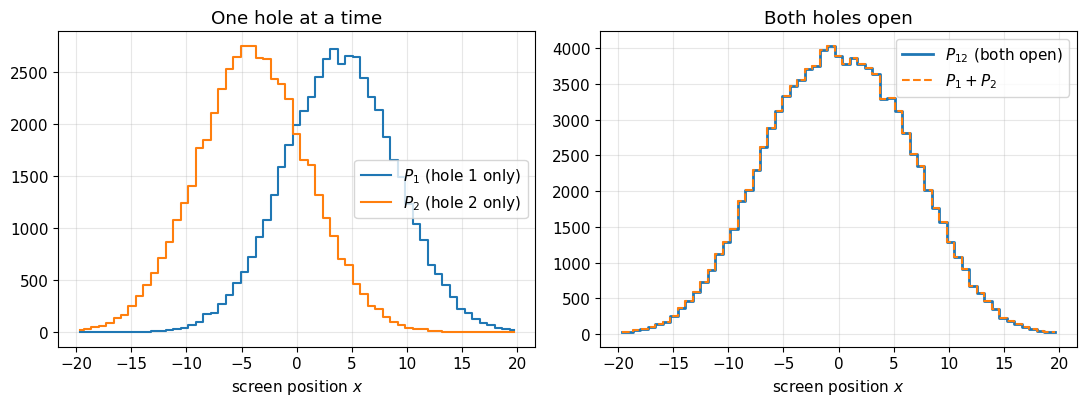

Max difference between P12 and (P1+P2): 0
=> For bullets the probabilities simply add: P12 = P1 + P2.


In [8]:
# Each bullet independently passes hole 1 (lands near +x0) or hole 2 (near -x0),
# then scatters with a Gaussian spread. This is ordinary classical probability.
N = 100_000
x0, sigma = 4.0, 5.0
slit    = np.random.randint(0, 2, N)                 # 0 -> hole 1, 1 -> hole 2
centers = np.where(slit == 0, +x0, -x0)
x_land  = centers + np.random.normal(0, sigma, N)    # landing position on screen 2 (detector)

x1, x2 = x_land[slit == 0], x_land[slit == 1]
bins = np.linspace(-20, 20, 60)
P1,  e = np.histogram(x1,    bins=bins)
P2,  _ = np.histogram(x2,    bins=bins)
P12, _ = np.histogram(x_land, bins=bins)
xc = 0.5 * (e[:-1] + e[1:])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].step(xc, P1, where="mid", label="$P_1$ (hole 1 only)")
ax[0].step(xc, P2, where="mid", label="$P_2$ (hole 2 only)")
ax[0].set_title("One hole at a time");  ax[0].legend(); ax[0].set_xlabel("screen position $x$")
ax[1].step(xc, P12, where="mid", lw=2, label="$P_{12}$ (both open)")
ax[1].step(xc, P1 + P2, where="mid", ls="--", label="$P_1+P_2$")
ax[1].set_title("Both holes open");    ax[1].legend(); ax[1].set_xlabel("screen position $x$")
plt.tight_layout(); plt.show()

print("Max difference between P12 and (P1+P2):", int(np.max(np.abs(P12, (P1 + P2)))))
print("=> For bullets the probabilities simply add: P12 = P1 + P2.")

## 1.2 Waves, *intensities interfere*

Now a wave passes through both holes at once. Each hole emits a wave with a **complex amplitude**
$h_i$; the detector reads **intensity** $I=|h|^2$. With both holes open the amplitudes add
*before* squaring:

$$I_{12}=|h_1+h_2|^2 = I_1 + I_2 + 2\sqrt{I_1 I_2}\,\cos\delta .$$

The last term -> the **interference term** -> has no classical analogue. We model the far-field
pattern: a single-slit **diffraction envelope** times a two-slit **interference** factor.

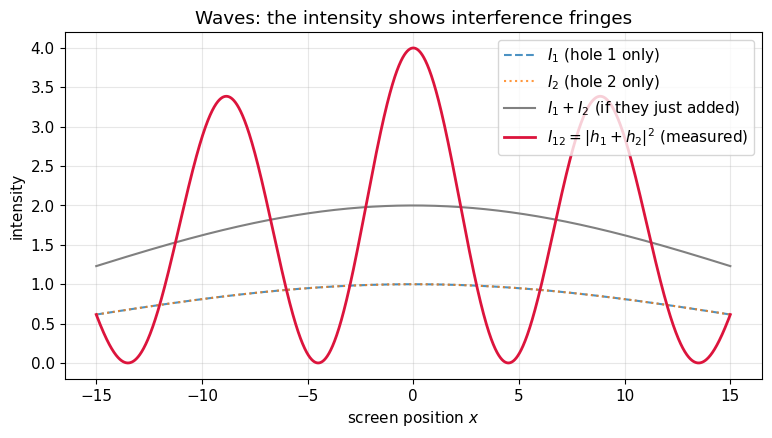

At the center: I12 = 4.00,  I1+I2 = 2.00  -> the bright fringe is TWICE the sum.


In [10]:
# Far-field two-slit amplitudes. 'delta' is the path-difference phase between the
# two holes; 'env' is the single-slit diffraction envelope (slit width a).
x = np.linspace(-15, 15, 3000)
wavelength, L, d, a = 0.6, 60.0, 4.0, 0.9
k     = 2 * np.pi / wavelength
delta = k * d * x / L
beta  = k * a * x / (2 * L)
env   = np.sinc(beta / np.pi) ** 2          # np.sinc(z) = sin(pi z)/(pi z)
amp   = np.sqrt(env)

phi1 = amp * np.exp(-1j * delta / 2)        # complex amplitude, hole 1
phi2 = amp * np.exp(+1j * delta / 2)        # complex amplitude, hole 2
I1, I2 = np.abs(phi1) ** 2, np.abs(phi2) ** 2
I12    = np.abs(phi1 + phi2) ** 2           # amplitudes add, THEN square

plt.figure()
plt.plot(x, I1, ls="--", alpha=0.8, label="$I_1$ (hole 1 only)")
plt.plot(x, I2, ls=":",  alpha=0.8, label="$I_2$ (hole 2 only)")
plt.plot(x, I1 + I2, color="gray", label="$I_1+I_2$ (if they just added)")
plt.plot(x, I12, color="crimson", lw=2, label="$I_{12}=|h_1+h_2|^2$ (measured)")
plt.title("Waves: the intensity shows interference fringes")
plt.xlabel("screen position $x$"); plt.ylabel("intensity"); plt.legend(); plt.show()

print(f"At the center: I12 = {I12[np.argmin(np.abs(x))]:.2f},  "
      f"I1+I2 = {(I1+I2)[np.argmin(np.abs(x))]:.2f}  -> the bright fringe is TWICE the sum.")

## 1.3 Electrons, lumps that build a wave pattern

Electrons arrive in **identical lumps** (discrete clicks), like bullets. Yet the *distribution*
of clicks follows the **wave** pattern. This is due to the fact that electrons need to be described by a wavefunction:

$$P=|\phi|^2,\qquad \phi=\phi_1+\phi_2 \;\;\text{(when the path is not determined)}.$$

We reuse the very same complex amplitudes from 1.2 and let detector "clicks" accumulate one at a
time. Watch the interference pattern *emerge from random lumps*.

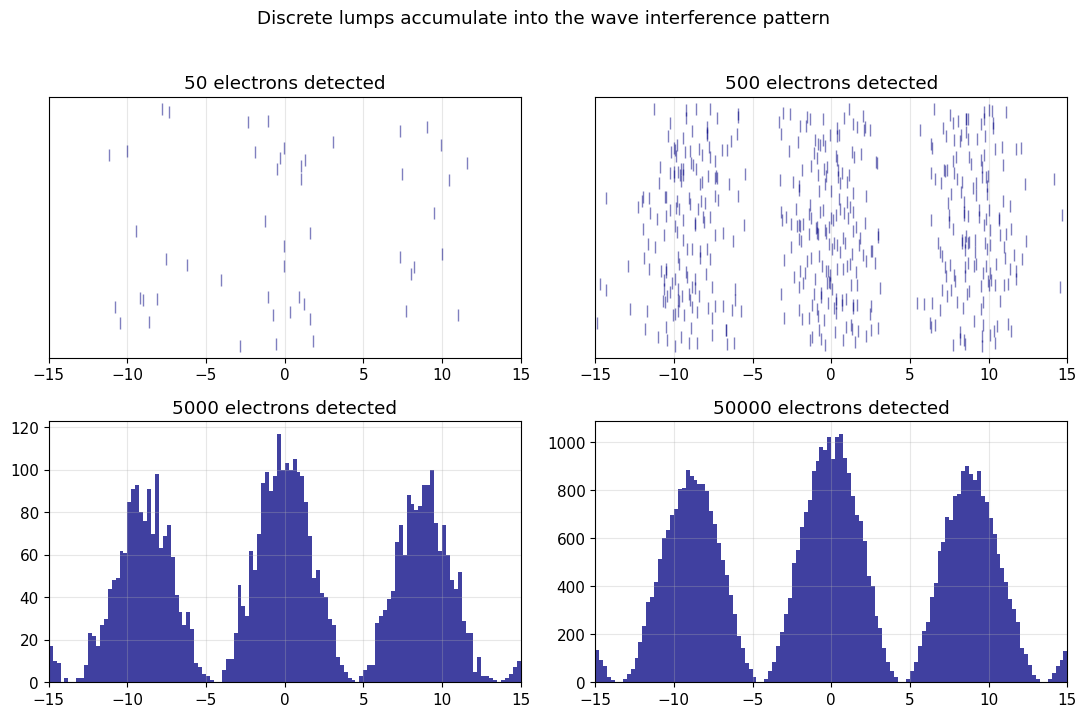

Each electron is a single click; only the *statistics* of many clicks reveal the wave.


In [11]:
# Treat |phi1 + phi2|^2 as the probability of a click at each x; sample clicks one by one.
P12  = np.abs(phi1 + phi2) ** 2
pmf  = P12 / P12.sum()
def sample_clicks(n):
    return x[np.random.choice(len(x), size=n, p=pmf)]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, n in zip(axes.ravel(), [50, 500, 5000, 50000]):
    clicks = sample_clicks(n)
    if n <= 500:                          # show individual lumps
        ax.plot(clicks, np.random.uniform(0, 1, n), "|", ms=8, alpha=0.5, color="navy")
        ax.set_yticks([])
    else:                                 # show the histogram that emerges
        ax.hist(clicks, bins=120, color="navy", alpha=0.75)
    ax.set_title(f"{n} electrons detected"); ax.set_xlim(-15, 15)
fig.suptitle("Discrete lumps accumulate into the wave interference pattern", y=1.02)
plt.tight_layout(); plt.show()
print("Each electron is a single click; only the *statistics* of many clicks reveal the wave.")

## 1.4 Watching the electrons, *which-path information destroys interference*

Add a detector that records **which hole** each electron used. Feynman's key (and most
misunderstood) point: the fringes vanish **not because the apparatus is clumsy**, but because the
two paths have become *distinguishable*. Once "which path" is knowable, **probabilities add**
($P_{12}=P_1+P_2$) and interference is gone.

We contrast two runs of 50,000 electrons: one *unwatched* (amplitudes add), one *watched*
(each electron definitely goes through one hole).

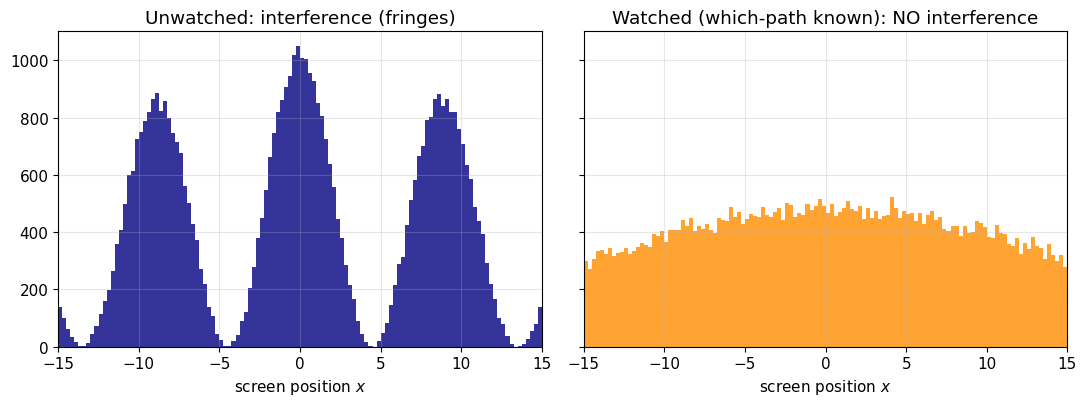

Knowing the path collapses |phi1+phi2|^2  ->  |phi1|^2 + |phi2|^2.  The fringes disappear.


In [12]:
n = 50_000
# Unwatched: clicks distributed by the interference law |phi1+phi2|^2
unwatched = sample_clicks(n)

# Watched: each electron provably goes through hole 1 OR hole 2 (50/50),
# then lands by that single hole's pattern. No relative phase survives -> no fringes.
pmf1, pmf2 = I1 / I1.sum(), I2 / I2.sum()
which = np.random.randint(0, 2, n)
watched = np.empty(n)
watched[which == 0] = x[np.random.choice(len(x), (which == 0).sum(), p=pmf1)]
watched[which == 1] = x[np.random.choice(len(x), (which == 1).sum(), p=pmf2)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
ax[0].hist(unwatched, bins=120, color="navy",   alpha=0.8)
ax[0].set_title("Unwatched: interference (fringes)")
ax[1].hist(watched,   bins=120, color="darkorange", alpha=0.8)
ax[1].set_title("Watched (which-path known): NO interference")
for a in ax: a.set_xlim(-15, 15); a.set_xlabel("screen position $x$")
plt.tight_layout(); plt.show()
print("Knowing the path collapses |phi1+phi2|^2  ->  |phi1|^2 + |phi2|^2.  The fringes disappear.")

## 1.5 The interference term, made explicit

The difference between the quantum and classical results is exactly one term:

$$P_{12} \;=\; \underbrace{P_1+P_2}_{\text{classical}} \;+\; \underbrace{2\,\mathrm{Re}(\phi_1^{*}\phi_2)}_{\text{interference}} \;=\; P_1+P_2+2\sqrt{P_1 P_2}\,\cos\delta .$$

Constructive where $\cos\delta>0$, destructive where $\cos\delta<0$. This oscillating term
is the "magic" of quantum computing, and it is the same resource a quantum computer runs on.

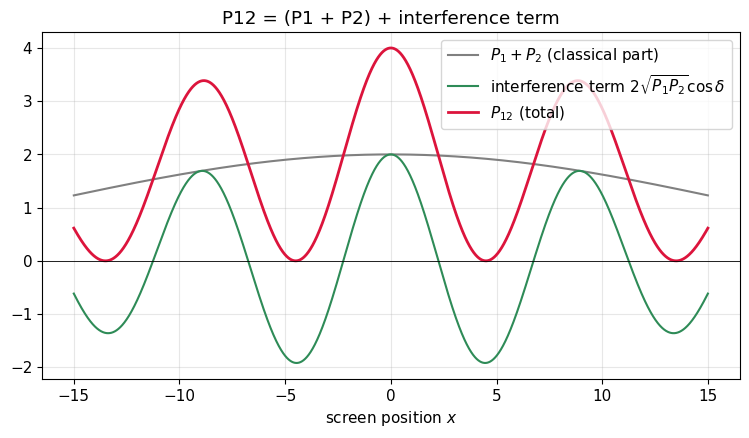

Identity  P12 == P1 + P2 + 2*Re(phi1* phi2)  holds exactly: True


In [ ]:
P1a, P2a = np.abs(phi1) ** 2, np.abs(phi2) ** 2
cross    = 2 * np.real(np.conj(phi1) * phi2)          # the interference term
assert np.allclose(P12, P1a + P2a + cross)           # identity holds exactly

plt.figure()
plt.plot(x, P1a + P2a, color="gray", label="$P_1+P_2$ (classical part)")
plt.plot(x, cross, color="seagreen", label=r"interference term $2\sqrt{P_1P_2}\cos\delta$")
plt.plot(x, P12, color="crimson", lw=2, label="$P_{12}$ (total)")
plt.axhline(0, color="k", lw=0.6)
plt.title("P12 = (P1 + P2) + interference term"); plt.xlabel("screen position $x$")
plt.legend(); plt.show()
print("Identity  P12 == P1 + P2 + 2*Re(phi1* phi2)  holds exactly:",
      np.allclose(P12, P1a + P2a + cross))

## 1.6 What Part I gives us for quantum computing

- **Amplitudes are complex numbers; probability is $|\text{amplitude}|^2$** (the Born rule).
- **Indistinguishable alternatives interfere** ($\phi=\phi_1+\phi_2$); **distinguishable ones do not**
  ($P=P_1+P_2$).
- **Measurement / which-path information is destructive**, the same effect that, uncontrolled,
  appears later as *decoherence*, the enemy of every quantum computer.

Difference betwee Part I and computing: the electron's position is continuous (infinitely many outcomes).
To build a **bit**, we need a quantum system with the *smallest possible* number of outcomes: **two**.
That is exactly what the Stern–Gerlach experiment is about.

---
# Part II, The Stern–Gerlach Experiment → the Qubit

Silver atoms (each carrying one spin-½ electron) pass through an inhomogeneous magnetic field.
Classically we'd expect a continuous smear. **Instead the beam splits into exactly two spots.**
A two-outcome quantum system has appeared → this is the physical **qubit**.

## 2.1 The qubit as a 2-component complex vector

We label the two Stern–Gerlach-$z$ outcomes the **computational basis**:
$|{+}z\rangle\equiv|0\rangle$ and $|{-}z\rangle\equiv|1\rangle$. Measuring along *other* axes forces us
to write **superpositions** with specific amplitudes (the discrete echo of the double-slit phase):

$$|{+}x\rangle=\tfrac{1}{\sqrt2}(|0\rangle+|1\rangle),\quad
  |{-}x\rangle=\tfrac{1}{\sqrt2}(|0\rangle-|1\rangle),\quad
  |{+}y\rangle=\tfrac{1}{\sqrt2}(|0\rangle+i|1\rangle).$$

Note the complex $i$: the same complex numbers Feynman insisted on now distinguish the $x$- and
$y$-measurements.

In [13]:
# Computational basis and the three measurement-axis state pairs
ket0 = np.array([1, 0], dtype=complex)          # |0> = |+z>  (spin up along z)
ket1 = np.array([0, 1], dtype=complex)          # |1> = |-z>  (spin down along z)
ketXp = (ket0 + ket1) / np.sqrt(2)              # |+x>
ketXm = (ket0, ket1) / np.sqrt(2)              # |-x>
ketYp = (ket0 + 1j * ket1) / np.sqrt(2)         # |+y>
ketYm = (ket0, 1j * ket1) / np.sqrt(2)         # |-y>

# Pauli matrices (spin observables, up to hbar/2) and the gates we will need later
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]],   dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]],  dtype=complex)
H  = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

for name, v in [("|0>", ket0), ("|1>", ket1), ("|+x>", ketXp), ("|+y>", ketYp)]:
    print(f"{name:5s} = {np.round(v, 3)}")

|0>   = [1.+0.j 0.+0.j]
|1>   = [0.+0.j 1.+0.j]
|+x>  = [0.707+0.j 0.707+0.j]
|+y>  = [0.707+0.j    0.   +0.707j]


## 2.2 A single Stern–Gerlach box: quantization + the Born rule

A measurement along direction $\hat n$ asks one yes/no question and returns one of **two** outcomes,
with probability given by the Born rule $\;P(+\hat n)=|\langle +\hat n|\psi\rangle|^2$.
Below: the operators that implement an SG measurement, then a picture of the **two spots**.

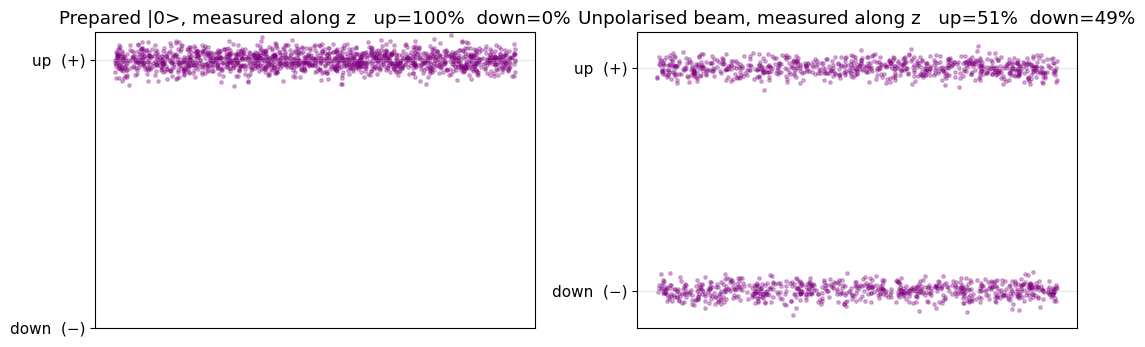

Quantization: the screen always shows TWO discrete spots, never a continuous smear.


In [16]:
def unit(n):                       # normalise a direction vector
    n = np.asarray(n, float);  return n / np.linalg.norm(n)

def axis_operator(n):              # n . sigma  (eigenvalues +-1 = up/down along n)
    nx, ny, nz = unit(n);  return nx * X + ny * Y + nz * Z

def plus_eigenstate(n):            # the spin-up-along-n state
    vals, vecs = np.linalg.eigh(axis_operator(n))
    return vecs[:, int(np.argmax(vals))]

def prob_up(state, n):             # Born-rule probability of the '+n' outcome
    return float(np.abs(np.vdot(plus_eigenstate(n), state)) ** 2)

def measure_axis(state, n):        # ONE measurement: returns (+1/-1, collapsed state)
    vals, vecs = np.linalg.eigh(axis_operator(n))
    probs = np.abs(vecs.conj().T @ state) ** 2
    o = np.random.choice(len(vals), p=probs / probs.sum())
    return float(np.round(vals[o])), vecs[:, o].copy()

Z_AXIS, X_AXIS, Y_AXIS = (0, 0, 1), (1, 0, 0), (0, 1, 0)

def sg_screen(states, n=Z_AXIS, title=""):
    # Send a list of atoms through an SG box along n; plot where they land.
    ups = np.array([measure_axis(s, n)[0] for s in states])
    y = ups + np.random.normal(0, 0.06, len(ups))         # +1 (up) / -1 (down) + jitter
    plt.scatter(np.random.uniform(0, 1, len(ups)), y, s=6, alpha=0.3, color="purple")
    plt.yticks([-1, 1], ["down  (−)", "up  (+)"]); plt.xticks([])
    plt.title(f"{title}   up={np.mean(ups>0):.0%}  down={np.mean(ups<0):.0%}")

# (a) a pure |0> beam measured along z -> one spot (all up); (b) unpolarised beam -> two spots
def random_states(m):              # an 'unpolarised' beam = random points on the Bloch sphere
    th = np.arccos(np.random.uniform(-1, 1, m)); ph = np.random.uniform(0, 2*np.pi, m)
    return [np.cos(t/2)*ket0 + np.exp(1j*p)*np.sin(t/2)*ket1 for t, p in zip(th, ph)]

plt.figure(figsize=(11, 3.6))
plt.subplot(1, 2, 1); sg_screen([ket0]*1500, Z_AXIS, "Prepared |0>, measured along z")
plt.subplot(1, 2, 2); sg_screen(random_states(1500), Z_AXIS, "Unpolarised beam, measured along z")
plt.tight_layout(); plt.show()
print("Quantization: the screen always shows TWO discrete spots, never a continuous smear.")

## 2.3 Sequential Stern–Gerlach: superposition, incompatibility, erasure

Three cascades reveal the qubit's full structure:

- **(A) Repeatable:** $|0\rangle \to$ SG-$z \to$ SG-$z$ gives **up every time**.
- **(B) Incompatible:** $|0\rangle \to$ SG-$x$ splits **50/50**, definite along $z$ means undefined along $x$.
- **(C) Erasure:** $|0\rangle \to$ SG-$x$ (keep $+x$) $\to$ SG-$z$ is **50/50 again**, the $x$-measurement
  *erased* the $z$-information. $S_z$ and $S_x$ are **incompatible (non-commuting) observables**.

(A) z -> z        : final beam  up=100.0%  down= 0.0%   (atoms reaching last box: 20000)
(B) z -> x        : final beam  up=50.0%  down=50.0%   (atoms reaching last box: 20000)
(C) z -> x -> z   : final beam  up=50.0%  down=50.0%   (atoms reaching last box: 10087)


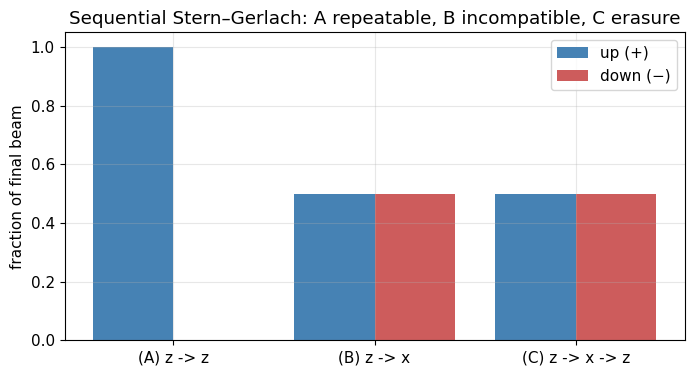

In [17]:
def cascade(initial, axes, n_atoms=20000):
    # Send atoms through a chain of SG boxes; keep only the '+' branch at each
    # stage except the last, and report the final +/- split.
    states = [initial] * n_atoms
    for ax in axes[:-1]:
        kept = []
        for s in states:
            val, coll = measure_axis(s, ax)
            if val > 0:                          # post-select the '+' (upper) beam
                kept.append(coll)
        states = kept
    finals = np.array([measure_axis(s, axes[-1])[0] for s in states])
    return np.mean(finals > 0), np.mean(finals < 0), len(states)

expts = {
    "(A) z -> z":           [Z_AXIS, Z_AXIS],
    "(B) z -> x":           [Z_AXIS, X_AXIS],
    "(C) z -> x -> z":      [Z_AXIS, X_AXIS, Z_AXIS],
}
labels, ups, downs = [], [], []
for name, axes in expts.items():
    up, dn, kept = cascade(ket0, axes)
    labels.append(name); ups.append(up); downs.append(dn)
    print(f"{name:18s}: final beam  up={up:5.1%}  down={dn:5.1%}   (atoms reaching last box: {kept})")

i = np.arange(len(labels))
plt.figure(figsize=(8, 4))
plt.bar(i, 0.2, ups,   0.4, label="up (+)",   color="steelblue")
plt.bar(i + 0.2, downs, 0.4, label="down (−)", color="indianred")
plt.xticks(i, labels); plt.ylabel("fraction of final beam")
plt.title("Sequential Stern–Gerlach: A repeatable, B incompatible, C erasure")
plt.legend(); plt.show()

## 2.4 The measurement law: $P(+) = \cos^2(\theta/2)$

Prepare $|0\rangle$ (up along $z$) and measure along an axis tilted by angle $\theta$ from $z$.
The probability of "up" is $\cos^2(\theta/2)$, the spin version of Malus's law, and the precise
quantitative content of "superposition." Our Monte-Carlo measurements should trace the theory curve.

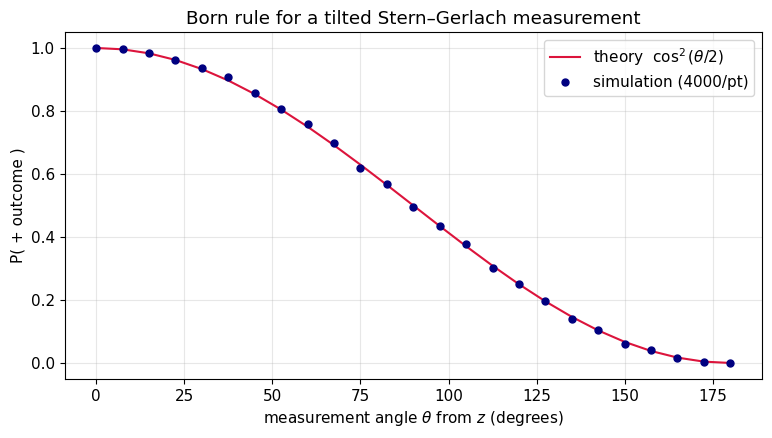

theta=0 -> P=1 (definitely up),  theta=90 -> P=0.5 (the SG z->x split),  theta=180 -> P=0.


In [ ]:
thetas = np.linspace(0, np.pi, 25)
trials = 4000
theory = np.cos(thetas / 2) ** 2
empir  = [np.random.binomial(trials, prob_up(ket0, (np.sin(t), 0, np.cos(t)))) / trials
          for t in thetas]

plt.figure()
plt.plot(np.degrees(thetas), theory, "-",  color="crimson", label=r"theory  $\cos^2(\theta/2)$")
plt.plot(np.degrees(thetas), empir,  "o", ms=5, color="navy", label=f"simulation ({trials}/pt)")
plt.xlabel(r"measurement angle $\theta$ from $z$ (degrees)")
plt.ylabel("P( + outcome )"); plt.title("Born rule for a tilted Stern–Gerlach measurement")
plt.legend(); plt.show()
print("theta=0 -> P=1 (definitely up),  theta=90 -> P=0.5 (the SG z->x split),  theta=180 -> P=0.")

## 2.5 The Bloch sphere, Stern–Gerlach axes *are* the coordinate axes

Every qubit state is a point on a sphere. The Bloch vector is
$\vec r = (\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$. The crucial picture: **the direction
you point the Stern–Gerlach magnet is literally an axis of this sphere.** $|0\rangle,|1\rangle$ sit at
the $z$-poles; $|{\pm}x\rangle,|{\pm}y\rangle$ on the equator.

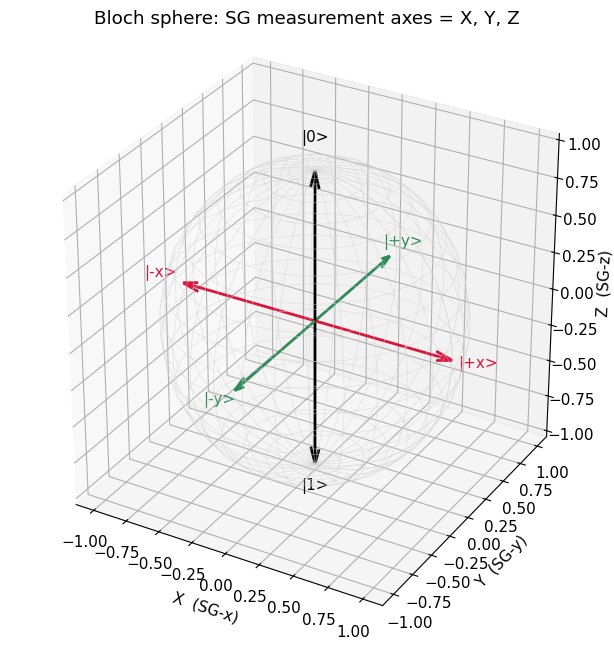

In [18]:
def bloch_vector(state):
    return np.array([np.real(np.vdot(state, M @ state)) for M in (X, Y, Z)])

fig = plt.figure(figsize=(6.5, 6.5)); ax = fig.add_subplot(111, projection="3d")
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color="lightgray", lw=0.5, alpha=0.6)
named = [("|0>", ket0, "k"), ("|1>", ket1, "k"),
         ("|+x>", ketXp, "crimson"), ("|-x>", ketXm, "crimson"),
         ("|+y>", ketYp, "seagreen"), ("|-y>", ketYm, "seagreen")]
for label, st, c in named:
    r = bloch_vector(st)
    ax.quiver(0, 0, 0, *r, color=c, lw=2, arrow_length_ratio=0.12)
    ax.text(*(r * 1.18), label, color=c, fontsize=11, ha="center")
ax.set_xlabel("X  (SG-x)"); ax.set_ylabel("Y  (SG-y)"); ax.set_zlabel("Z  (SG-z)")
ax.set_title("Bloch sphere: SG measurement axes = X, Y, Z")
ax.set_box_aspect((1, 1, 1)); plt.tight_layout(); plt.show()

## 2.6 What Part II gives us for quantum computing

- A **two-level system** = the **qubit**, with basis $|0\rangle,|1\rangle$.
- **Superposition**: definite along one axis ⇒ $\cos^2(\theta/2)$ along another.
- **Incompatible observables** and **measurement collapse**, the same lesson as which-path, now in 2D.
- The **Bloch sphere** is equivalent to the SG setup in geometric terms. Rotations of this sphere are essentially equivalent to: **Quantum Gates**.

---
# Part III, Bridge to Quantum Computing

We now have states (Part II) and the interference law (Part I). Computation needs **operations**
between preparation and measurement. Allowed single-qubit operations are the **unitary** $2\times2$
matrices, geometrically, **rotations of the Bloch sphere**.

## 3.1 Single-qubit gates $X$, $Z$, $H$

- $X=\bigl(\begin{smallmatrix}0&1\\1&0\end{smallmatrix}\bigr)$, **NOT**: $|0\rangle\!\leftrightarrow\!|1\rangle$.
- $Z=\bigl(\begin{smallmatrix}1&0\\0&-1\end{smallmatrix}\bigr)$, **phase flip**: invisible in the $z$-basis,
  but flips $|{+}x\rangle\!\leftrightarrow\!|{-}x\rangle$ (relative phase is physical!).
- $H=\tfrac{1}{\sqrt2}\bigl(\begin{smallmatrix}1&1\\1&-1\end{smallmatrix}\bigr)$, **Hadamard**:
  $|0\rangle\to|{+}x\rangle,\ |1\rangle\to|{-}x\rangle$. It builds superpositions and is its own inverse.

In [ ]:
def show(label, vec): print(f"{label:14s} = {np.round(vec, 3)}")
show("X|0>", X @ ket0);  show("X|1>", X @ ket1)
show("Z|+x>", Z @ ketXp)                       # should equal |-x>
show("H|0>", H @ ket0);  show("H|1>", H @ ket1) # should equal |+x>, |-x>
print("H is its own inverse (H@H == I):", np.allclose(H @ H, I2))
print("Z turns |+x> into |-x>:           ", np.allclose(Z @ ketXp, ketXm))

X|0>           = [0.+0.j 1.+0.j]
X|1>           = [1.+0.j 0.+0.j]
Z|+x>          = [ 0.707+0.j -0.707+0.j]
H|0>           = [0.707+0.j 0.707+0.j]
H|1>           = [ 0.707+0.j -0.707+0.j]
H is its own inverse (H@H == I): True
Z turns |+x> into |-x>:            True


## 3.2 The Hadamard *is* the Stern–Gerlach $z\!\to\!x$ experiment

Measuring $|\psi\rangle$ **along $x$** is identical to **applying $H$ then measuring along $z$**.
Sequential SG *is* essentially a Hadamard. We can check it numerically for several states.

In [ ]:
print(f"{'state':6s} {'P(+x) directly':>16s} {'P(0) after H':>14s}")
for label, st in [("|0>", ket0), ("|1>", ket1), ("|+y>", ketYp), ("|+x>", ketXp)]:
    direct  = prob_up(st, X_AXIS)                       # measure along x
    after_H = np.abs(np.vdot(ket0, H @ st)) ** 2        # H, then measure along z (=P(0))
    print(f"{label:6s} {direct:16.3f} {after_H:14.3f}   match={np.isclose(direct, after_H)}")
print("\nThe Hadamard gate and the SG (z->x) basis change are the SAME operation.")

state    P(+x) directly   P(0) after H
|0>               0.500          0.500   match=True
|1>               0.500          0.500   match=True
|+y>              0.500          0.500   match=True
|+x>              1.000          1.000   match=True

The Hadamard gate and the SG (z->x) basis change are the SAME operation.


## 3.3 The single-qubit interferometer = a discrete double slit

Run $|0\rangle \xrightarrow{H}$ superposition $\xrightarrow{\text{phase }\varphi} \xrightarrow{H}$ measure.
Algebra gives $P(0)=\cos^2(\varphi/2)$, **the same interference fringe as the double slit**, with the
relative phase $\varphi$ playing the role of the path-difference $\delta$. This is the seed of most of the quantum algorithms: *combine, phase, recombine, and let amplitudes interfere.*

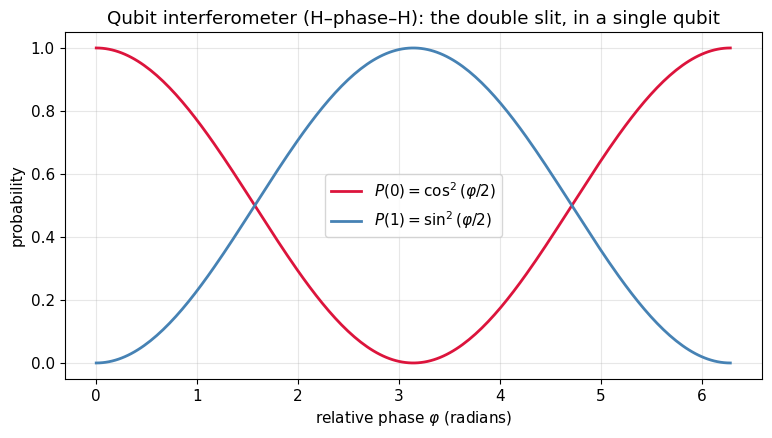

Same cos^2 interference as Part I, phase replaces path difference.


In [ ]:
phases = np.linspace(0, 2 * np.pi, 200)
P0, P1p = [], []
for ph in phases:
    Ph  = np.array([[1, 0], [0, np.exp(1j * ph)]], dtype=complex)   # relative phase gate
    psi = H @ Ph @ H @ ket0                                         # H, phase, H
    P0.append(np.abs(np.vdot(ket0, psi)) ** 2)
    P1p.append(np.abs(np.vdot(ket1, psi)) ** 2)

plt.figure()
plt.plot(phases, P0,  lw=2, color="crimson",   label=r"$P(0)=\cos^2(\varphi/2)$")
plt.plot(phases, P1p, lw=2, color="steelblue", label=r"$P(1)=\sin^2(\varphi/2)$")
plt.xlabel(r"relative phase $\varphi$ (radians)"); plt.ylabel("probability")
plt.title("Qubit interferometer (H–phase–H): the double slit, in a single qubit")
plt.legend(); plt.show()
print("Same cos^2 interference as Part I, phase replaces path difference.")

## 3.4 Capstone, Deutsch's algorithm: interference *solves a problem*

A function $f:\{0,1\}\to\{0,1\}$ is **constant** ($f(0)=f(1)$) or **balanced** ($f(0)\neq f(1)$).
Classically you must evaluate $f$ **twice** to decide. Deutsch's algorithm decides in **one** evaluation:
encode $f$ as a phase, then let $H$ make the two paths interfere, constructively onto $|0\rangle$ if
*constant*, onto $|1\rangle$ if *balanced*. It is literally the interferometer of 3.3 with the oracle
setting the phase.

In [ ]:
def deutsch(f):
    # Phase oracle:  U_f |x> = (-1)^{f(x)} |x>   (the 'phase-kickback' form)
    Uf  = np.array([[(-1) ** f(0), 0], [0, (-1) ** f(1)]], dtype=complex)
    psi = H @ Uf @ H @ ket0                       # H, oracle, H  (one query to f)
    return "balanced" if np.abs(np.vdot(ket1, psi)) ** 2 > 0.5 else "constant"

functions = {
    "f(x)=0   ": lambda x: 0,        # constant
    "f(x)=1   ": lambda x: 1,        # constant
    "f(x)=x   ": lambda x: x,        # balanced
    "f(x)=1-x ": lambda x: 1, x,    # balanced
}
print("Deutsch's algorithm, one query each:\n")
for name, f in functions.items():
    print(f"  {name}:  table=[f(0)={f(0)}, f(1)={f(1)}]  ->  algorithm says: {deutsch(f).upper()}")
print("\nA single interference step reads a GLOBAL property of f. That is quantum advantage in miniature.")

Deutsch's algorithm, one query each:

  f(x)=0   :  table=[f(0)=0, f(1)=0]  ->  algorithm says: CONSTANT
  f(x)=1   :  table=[f(0)=1, f(1)=1]  ->  algorithm says: CONSTANT
  f(x)=x   :  table=[f(0)=0, f(1)=1]  ->  algorithm says: BALANCED
  f(x)=1-x :  table=[f(0)=1, f(1)=0]  ->  algorithm says: BALANCED

A single interference step reads a GLOBAL property of f. That is quantum advantage in miniature.


## 3.5 The big picture & the next steps

**The map of the whole discussion:**

| Experiment | What it teaches | Quantum-computing concept |
|---|---|---|
| Double slit | amplitudes, $P=|\phi|^2$, interference, which-path | Born rule, superposition, **decoherence** |
| Stern–Gerlach (one box) | two discrete outcomes | the **qubit**, basis $|0\rangle,|1\rangle$ |
| Stern–Gerlach (sequential) | incompatible observables, basis change | **Bloch sphere**, the **Hadamard** gate |
| Qubit interferometer | engineered interference | **quantum algorithms** (Deutsch, and beyond) |

**Key Takeaway:** *Quantum computation arranges amplitudes so that wrong answers
interfere destructively and right answers constructively* i.e. the double slit in a scaled up form.

**For Practice:** Please go back and change `wavelength`, `d`, `a` in Part I, or the cascade `axes` in 2.3, and
re-run. Building intuition through practice.